In [ ]:
!pip install -q pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 11.9 MB/s eta 0:00:00


In [ ]:
!pip install -q rouge_score

  Preparing metadata (setup.py) ... done


In [ ]:
import os, json
from datasets import load_dataset
from PIL import Image

os.makedirs("data/images", exist_ok=True)
os.makedirs("data/subsets", exist_ok=True)

if os.path.exists("data/subsets/facad_100.json"):
    print("Data đã có sẵn")
else:
    print("Đang tải lại dataset")
    dataset = load_dataset(
        "Luna288/image-captioning-FACAD-base",
        split="train",
        streaming=True
    )
    samples = list(dataset.take(100))

    metadata = []
    for idx, sample in enumerate(samples):
        img_path = f"data/images/img_{idx:04d}.jpg"
        img = sample['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img.save(img_path, quality=95)
        metadata.append({
            "id": idx,
            "image_path": img_path,
            "caption": sample['text'],
            "image_width": img.size[0],
            "image_height": img.size[1],
        })

    with open("data/subsets/facad_100.json", "w") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

with open("data/subsets/facad_100.json") as f:
    metadata = json.load(f)

print(f"metadata loaded: {len(metadata)} mẫu")

Đang tải lại dataset


README.md:   0%|          | 0.00/392 [00:00<?, ?B/s]

metadata loaded: 100 mẫu


In [ ]:
!pip install -q datasets transformers accelerate \
    Pillow requests nltk evaluate \
    torch torchvision

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

CUDA available: True
GPU: Tesla T4


In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset(
    "Luna288/image-captioning-FACAD-base",
    split="train",
    streaming=True
)

samples = list(dataset.take(200))

In [ ]:
import os
import json
from PIL import Image

os.makedirs("data/images", exist_ok=True)
os.makedirs("data/subsets", exist_ok=True)

print("Đang trích xuất 100 mẫu từ FACAD")
subset_100 = samples[:100]

metadata = []
for idx, sample in enumerate(subset_100):
    img_path = f"data/images/img_{idx:04d}.jpg"
    img = sample['image']
    if img.mode != 'RGB':
        img = img.convert('RGB')

    img.save(img_path, quality=95)
    metadata.append({
        "id": idx,
        "image_path": img_path,
        "caption": sample['text'],
        "image_width": img.size[0],
        "image_height": img.size[1],
        "caption_length": len(sample['text'].split())
    })

with open("data/subsets/facad_100.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Đã lưu {len(metadata)} mẫu")
print(f"Ảnh: data/images/")
print(f"Metadata: data/subsets/facad_100.json")

print(f"\nKiểm tra 3 mẫu đầu:")
for m in metadata[:3]:
    print(f"  ID {m['id']}: [{m['image_width']}x{m['image_height']}] | {m['caption'][:60]}...")

Đang trích xuất 100 mẫu từ FACAD
Đã lưu 100 mẫu
Ảnh: data/images/
Metadata: data/subsets/facad_100.json

Kiểm tra 3 mẫu đầu:
  ID 0: [180x270] | flower fall and spot spatter this wear everywhere top cut wi...
  ID 1: [180x270] | inspired by classic american style this prepster staple is k...
  ID 2: [180x270] | pretty floral lace bloom across this cropped camisole that s...


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor
from PIL import Image
import json

class FacadSubsetDataset(Dataset):
    """
    Dataset loader cho 100 mẫu FACAD
    Tương thích với cả Teacher (BLIP-2) và Student (BLIP-base)
    """

    def __init__(self, metadata_path: str, processor, max_length: int = 64):
        """
        Args:
            metadata_path: đường dẫn đến facad_100.json
            processor: HuggingFace processor (BlipProcessor)
            max_length: độ dài tối đa của caption (tokens)
        """
        with open(metadata_path, 'r') as f:
            self.data = json.load(f)

        self.processor = processor
        self.max_length = max_length

        print(f"Loaded {len(self.data)} samples từ {metadata_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = Image.open(item['image_path']).convert('RGB')
        caption = item['caption']

        encoding = self.processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )

        return {
            'pixel_values': encoding['pixel_values'].squeeze(0),
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'caption': caption,
            'image_id': item['id']
        }


from transformers import BlipProcessor

print("Đang tải BLIP processor")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

dataset_train = FacadSubsetDataset(
    metadata_path="data/subsets/facad_100.json",
    processor=processor,
    max_length=64
)

dataloader = DataLoader(
    dataset_train,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("\nKiểm tra batch đầu tiên:")
batch = next(iter(dataloader))
print(f"  pixel_values shape: {batch['pixel_values'].shape}")
print(f"  input_ids shape   : {batch['input_ids'].shape}")
print(f"  attention_mask    : {batch['attention_mask'].shape}")
print(f"  captions mẫu      : {batch['caption'][0][:60]}...")

Đang tải BLIP processor


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loaded 100 samples từ data/subsets/facad_100.json

Kiểm tra batch đầu tiên:
  pixel_values shape: torch.Size([8, 3, 384, 384])
  input_ids shape   : torch.Size([8, 64])
  attention_mask    : torch.Size([8, 64])
  captions mẫu      : fanciful bloom sweeten this shapely strapless mini styled wi...


In [ ]:
import torch, json
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SHARED_PROCESSOR = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
PAD_ID = SHARED_PROCESSOR.tokenizer.pad_token_id

teacher_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(DEVICE).eval()
for p in teacher_model.parameters():
    p.requires_grad = False

student_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)

NUM_EPOCHS  = 10
BATCH_SIZE  = 4
LR          = 1e-5
ALPHA       = 0.4
MAX_LEN     = 64
WARMUP_RATIO = 0.1

with open("data/subsets/facad_100.json") as f:
    metadata = json.load(f)

total_steps   = (len(metadata) // BATCH_SIZE) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(student_model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

@torch.no_grad()
def get_pseudo_labels(pil_images):
    """Teacher sinh caption text, dùng SHARED_PROCESSOR"""
    inputs = SHARED_PROCESSOR(
        images=pil_images, return_tensors="pt", padding=True
    ).to(DEVICE)
    inputs["pixel_values"] = inputs["pixel_values"].half()

    ids = teacher_model.generate(
        **inputs, max_new_tokens=40, num_beams=3, early_stopping=True
    )
    return SHARED_PROCESSOR.batch_decode(ids, skip_special_tokens=True)

def make_labels(input_ids: torch.Tensor) -> torch.Tensor:
    """Mask pad + BOS thành -100 để loss không tính vào"""
    labels = input_ids.clone()
    labels[labels == PAD_ID] = -100
    labels[:, 0] = -100
    return labels

loss_log = []
print(f"Training: {NUM_EPOCHS} epochs | {total_steps} steps | warmup {warmup_steps} steps")

for epoch in range(NUM_EPOCHS):
    student_model.train()
    epoch_losses = []

    for start in range(0, len(metadata), BATCH_SIZE):
        batch = metadata[start : start + BATCH_SIZE]
        pil_imgs   = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps    = [b["caption"] for b in batch]
        pseudo_caps = get_pseudo_labels(pil_imgs)

        gt_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=gt_caps,
            return_tensors="pt", padding="max_length",
            max_length=MAX_LEN, truncation=True
        ).to(DEVICE)

        ps_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=pseudo_caps,
            return_tensors="pt", padding="max_length",
            max_length=MAX_LEN, truncation=True
        ).to(DEVICE)

        out_gt = student_model(
            pixel_values=gt_enc["pixel_values"],
            input_ids=gt_enc["input_ids"],
            attention_mask=gt_enc["attention_mask"],
            labels=make_labels(gt_enc["input_ids"])   # ✅ Fix lỗi 1
        )

        loss_gt = out_gt.loss
        out_pseudo = student_model(
            pixel_values=ps_enc["pixel_values"],
            input_ids=ps_enc["input_ids"],
            attention_mask=ps_enc["attention_mask"],
            labels=make_labels(ps_enc["input_ids"])
        )
        loss_pseudo = out_pseudo.loss

        loss = (1 - ALPHA) * loss_gt + ALPHA * loss_pseudo

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_losses.append(loss.item())

    avg = sum(epoch_losses) / len(epoch_losses)
    loss_log.append(avg)
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss={avg:.4f} "
          f"| LR={scheduler.get_last_lr()[0]:.2e}")


config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Training: 10 epochs | 250 steps | warmup 25 steps


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Epoch  1/10 | loss=3.5004 | LR=1.00e-05
Epoch  2/10 | loss=2.7566 | LR=8.89e-06
Epoch  3/10 | loss=2.2411 | LR=7.78e-06
Epoch  4/10 | loss=1.8637 | LR=6.67e-06
Epoch  5/10 | loss=1.5704 | LR=5.56e-06
Epoch  6/10 | loss=1.3416 | LR=4.44e-06
Epoch  7/10 | loss=1.1596 | LR=3.33e-06
Epoch  8/10 | loss=1.0205 | LR=2.22e-06
Epoch  9/10 | loss=0.9191 | LR=1.11e-06
Epoch 10/10 | loss=0.8577 | LR=0.00e+00


In [ ]:
import torch.nn.functional as F

# Khởi tạo lại Student cho Word-KD để đảm bảo công bằng khi so sánh
student_model_wordkd = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)

# Hyperparams riêng cho Word-KD
TEMPERATURE = 4.0
ALPHA_WORD = 0.7

optimizer_word = AdamW(student_model_wordkd.parameters(), lr=LR, weight_decay=0.01)
scheduler_word = get_linear_schedule_with_warmup(
    optimizer_word,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def compute_word_kd_loss(student_logits, teacher_logits, pad_mask, T=TEMPERATURE):
    student_log_probs = F.log_softmax(student_logits / T, dim=-1)
    teacher_probs = F.softmax(teacher_logits.float() / T, dim=-1)
    kd_per_token = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(dim=-1)
    kd_per_token = kd_per_token * pad_mask
    return (kd_per_token.sum() / pad_mask.sum().clamp(min=1)) * (T ** 2)

print(f"Training Word-KD...")
for epoch in range(NUM_EPOCHS):
    student_model_wordkd.train()
    epoch_losses = []
    for start in range(0, len(metadata), BATCH_SIZE):
        batch = metadata[start : start + BATCH_SIZE]
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps = [b["caption"] for b in batch]

        gt_enc = SHARED_PROCESSOR(images=pil_imgs, text=gt_caps, return_tensors="pt", padding="max_length", max_length=MAX_LEN, truncation=True).to(DEVICE)
        gt_labels = make_labels(gt_enc["input_ids"])
        pad_mask = (gt_labels != -100).float()

        with torch.no_grad():
            teacher_out = teacher_model(pixel_values=gt_enc["pixel_values"].half(), input_ids=gt_enc["input_ids"], attention_mask=gt_enc["attention_mask"])
            teacher_logits = teacher_out.logits

        student_out = student_model_wordkd(pixel_values=gt_enc["pixel_values"], input_ids=gt_enc["input_ids"], attention_mask=gt_enc["attention_mask"], labels=gt_labels)
        loss_gt = student_out.loss
        loss_kd = compute_word_kd_loss(student_out.logits, teacher_logits, pad_mask)

        loss = (1 - ALPHA_WORD) * loss_gt + ALPHA_WORD * loss_kd
        optimizer_word.zero_grad(); loss.backward(); optimizer_word.step(); scheduler_word.step()
        epoch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {sum(epoch_losses)/len(epoch_losses):.4f}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Training Word-KD...
Epoch 1/10 | Loss: 1.8596
Epoch 2/10 | Loss: 1.5424
Epoch 3/10 | Loss: 1.3698
Epoch 4/10 | Loss: 1.2540
Epoch 5/10 | Loss: 1.1654
Epoch 6/10 | Loss: 1.0966
Epoch 7/10 | Loss: 1.0387
Epoch 8/10 | Loss: 0.9937
Epoch 9/10 | Loss: 0.9612
Epoch 10/10 | Loss: 0.9426


SO SÁNH CHI TIẾT: IMAGE | GT | TEACHER | SEQ-KD | WORD-KD



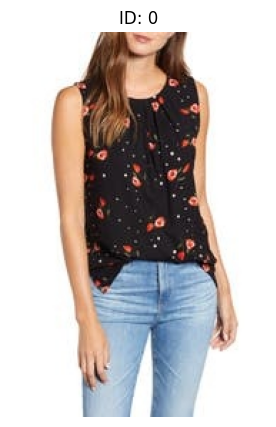

Ground Truth : flower fall and spot spatter this wear everywhere top cut with a gracefully pleated neckline
Teacher (L)  : the woman is wearing jeans and a top with a flower print
Seq-KD (S)   : women ' s sleeveless top with floral print
Word-KD (S)  : this fally blouse is perfect for layering up a casual look with a pop of color and a bow neckline



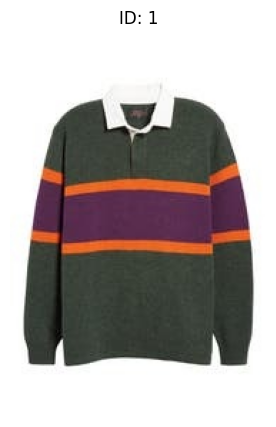

Ground Truth : inspired by classic american style this prepster staple is knit from soft warming wool and sharpened up with colorful stripe and a crisp cotton twill collar
Teacher (L)  : the sweater is green, orange, and purple with a white collar
Seq-KD (S)   : the sweater is green, orange and purple with a collar
Word-KD (S)  : a green sweater with a purple and orange stripe and a white collar



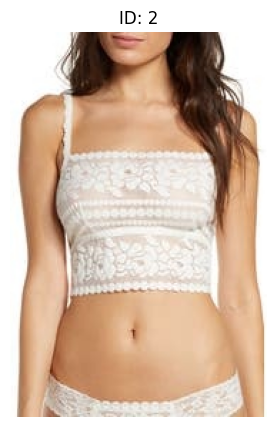

Ground Truth : pretty floral lace bloom across this cropped camisole that s soft stretchy and comfortable to wear
Teacher (L)  : an image of a woman wearing a white bra top and panties
Seq-KD (S)   : the woman is wearing a white bra top and panties
Word-KD (S)  : a cropped cropped camisole with a floral lace trim and a cropped camisole cut in the middle of the camisole



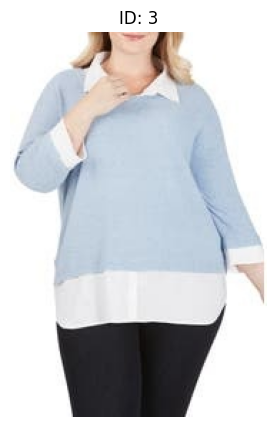

Ground Truth : if the sweater is clean so is the crisp white tee to top beneath it thanks to the sweater over tee look of this pullover style that s already paired
Teacher (L)  : the woman is wearing a light blue sweater and black pants
Seq-KD (S)   : the woman is wearing a light blue sweater and black pants
Word-KD (S)  : a plus size sweater that s perfect for layering and layering is perfect for layering and layering plus size sweater is perfect for layering and layering



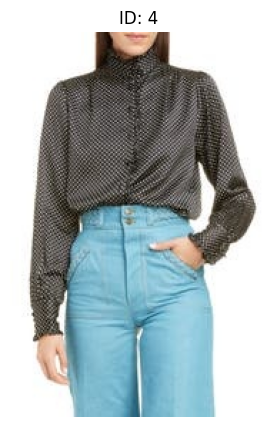

Ground Truth : frilly trim enhances the whimsical appeal of this polka dot blouse fashioned from light luminous silk
Teacher (L)  : the woman is wearing a black and white shirt and blue pants
Seq-KD (S)   : the woman is wearing blue jeans and a black shirt
Word-KD (S)  : frilly trim on a polka dot blouse add a flirty touch to your look



In [ ]:
import matplotlib.pyplot as plt

student_model.eval()
student_model_wordkd.eval()
teacher_model.eval()

print("SO SÁNH CHI TIẾT: IMAGE | GT | TEACHER | SEQ-KD | WORD-KD\n")

with torch.no_grad():
    for item in metadata[:5]:
        img = Image.open(item["image_path"]).convert("RGB")

        # Hiển thị ảnh
        plt.figure(figsize=(4, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"ID: {item['id']}")
        plt.show()

        inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)

        # 1. Teacher Prediction
        teacher_inputs = {k: v.clone() for k, v in inputs.items()}
        teacher_inputs["pixel_values"] = teacher_inputs["pixel_values"].half()
        ids_teacher = teacher_model.generate(**teacher_inputs, max_new_tokens=40, num_beams=4)
        pred_teacher = SHARED_PROCESSOR.decode(ids_teacher[0], skip_special_tokens=True)

        # 2. Seq-KD Prediction
        ids_seq = student_model.generate(**inputs, max_new_tokens=40, num_beams=4)
        pred_seq = SHARED_PROCESSOR.decode(ids_seq[0], skip_special_tokens=True)

        # 3. Word-KD Prediction
        ids_word = student_model_wordkd.generate(**inputs, max_new_tokens=40, num_beams=4)
        pred_word = SHARED_PROCESSOR.decode(ids_word[0], skip_special_tokens=True)

        print(f"Ground Truth : {item['caption']}")
        print(f"Teacher (L)  : {pred_teacher}")
        print(f"Seq-KD (S)   : {pred_seq}")
        print(f"Word-KD (S)  : {pred_word}")
        print("="*80 + "\n")

In [ ]:
import evaluate
from pycocoevalcap.cider.cider import Cider

# Tải các metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
cider_scorer = Cider()

def evaluate_model(model, metadata, is_teacher=False):
    model.eval()
    predictions = []
    references = []
    cider_refs = {}
    cider_preds = {}

    print(f"Đang đánh giá mô hình...")
    with torch.no_grad():
        for i, item in enumerate(metadata[:50]):
            img = Image.open(item["image_path"]).convert("RGB")
            inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)

            # Teacher model (Large) thường dùng float16
            if is_teacher:
                inputs["pixel_values"] = inputs["pixel_values"].half()

            generated_ids = model.generate(**inputs, max_new_tokens=40)
            pred = SHARED_PROCESSOR.decode(generated_ids[0], skip_special_tokens=True)

            predictions.append(pred)
            references.append([item["caption"]])

            cider_preds[i] = [pred]
            cider_refs[i] = [item["caption"]]

    bleu_score = bleu.compute(predictions=predictions, references=references)['bleu']
    rouge_score = rouge.compute(predictions=predictions, references=references)['rougeL']
    (cider_score, _) = cider_scorer.compute_score(cider_refs, cider_preds)

    return bleu_score, rouge_score, cider_score

print("--- Đánh giá Teacher (Large) ---")
teach_bleu_score, teach_rouge_score, teach_cider_score = evaluate_model(teacher_model, metadata, is_teacher=True)

print("--- Đánh giá Seq-KD ---")
seq_bleu_score, seq_rouge_score, seq_cider_score = evaluate_model(student_model, metadata)

print("--- Đánh giá Word-KD ---")
word_bleu_score, word_rouge_score, word_cider_score = evaluate_model(student_model_wordkd, metadata)

print("\n✅ Đã cập nhật xong tất cả chỉ số!")

--- Đánh giá Teacher (Large) ---
Đang đánh giá mô hình...
--- Đánh giá Seq-KD ---
Đang đánh giá mô hình...
--- Đánh giá Word-KD ---
Đang đánh giá mô hình...

✅ Đã cập nhật xong tất cả chỉ số!


In [ ]:
import pandas as pd

data = {
    "Metric": ["BLEU", "ROUGE-L", "CIDEr"],
    "Teacher (Large)": [teach_bleu_score, teach_rouge_score, teach_cider_score],
    "Seq-KD (Student)": [seq_bleu_score, seq_rouge_score, seq_cider_score],
    "Word-KD (Student)": [word_bleu_score, word_rouge_score, word_cider_score]
}

df_results = pd.DataFrame(data)

df_results = df_results.round(4)

print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ")
display(df_results)

BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ


,Metric,Teacher (Large),Seq-KD (Student),Word-KD (Student)
0,BLEU,0.0000,0.0375,0.0234
1,ROUGE-L,0.1356,0.1865,0.2396
2,CIDEr,0.0607,0.3998,0.4221


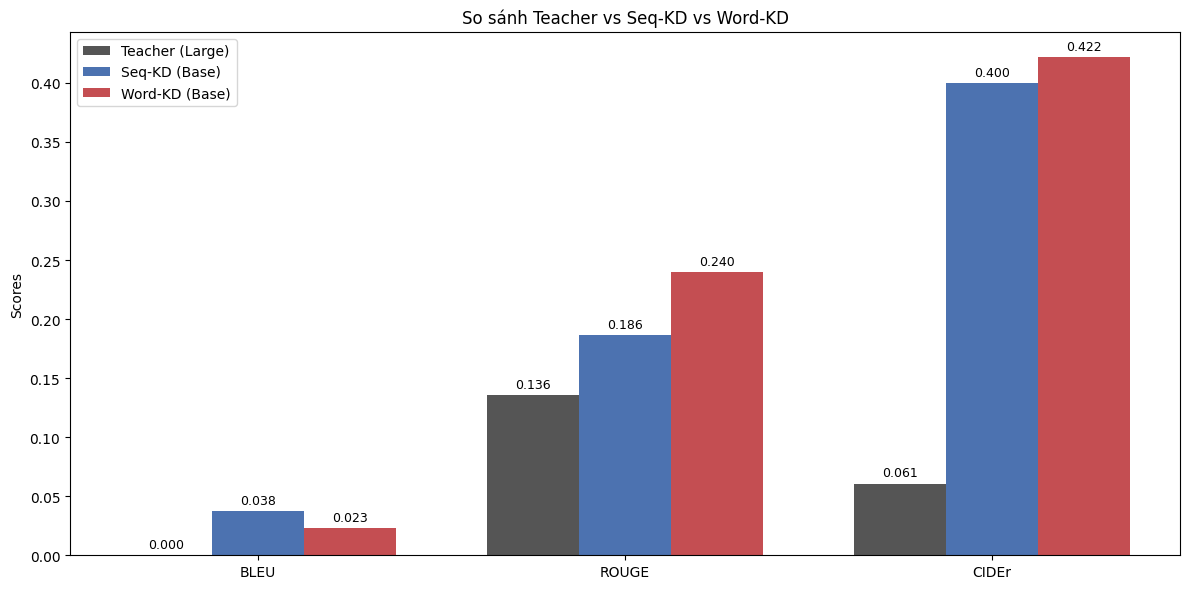

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['BLEU', 'ROUGE', 'CIDEr']
teacher_scores = [teach_bleu_score, teach_rouge_score, teach_cider_score]
seqkd_scores = [seq_bleu_score, seq_rouge_score, seq_cider_score]
wordkd_scores = [word_bleu_score, word_rouge_score, word_cider_score]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, teacher_scores, width, label='Teacher (Large)', color='#555555')
rects2 = ax.bar(x, seqkd_scores, width, label='Seq-KD (Base)', color='#4C72B0')
rects3 = ax.bar(x + width, wordkd_scores, width, label='Word-KD (Base)', color='#C44E52')

ax.set_ylabel('Scores')
ax.set_title('So sánh Teacher vs Seq-KD vs Word-KD')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()